## Decision tree Example

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn import datasets
from io import StringIO
from sklearn.tree import export_graphviz
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics
%matplotlib inline
import scipy.stats as st
import statsmodels as sm
import matplotlib
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/bank.csv')

In [3]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
## se va a decidir si se inscribe o no como cliente del banco


## EDA

In [5]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


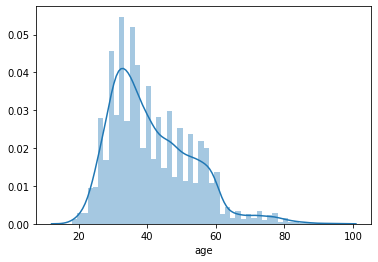

In [6]:
## Age
sns.distplot(data["age"])

In [13]:
def summary_stat(data):
    mean = np.mean(data)
    median = np.median(data)
    var = np.var(data)
    std = np.std(data)
    print("mean",str(mean))
    print("median",str(median))
    print("Variance",var)
    print("Std",std)
    return 


In [14]:
summary_stat(data["age"])

mean 41.231947679627304
39.0
141.91565019328286
11.912835522799886


In [20]:
def best_fit_distribution(data, bins=200, ax=None):
    """Model data by finding best fit distribution to data"""
    # Get histogram of original data
    y, x = np.histogram(data, bins=bins, density=True)
    x = (x + np.roll(x, -1))[:-1] / 2.0

    # Distributions to check
    DISTRIBUTIONS = [        
        st.alpha,st.anglit,st.arcsine,st.beta,st.betaprime,st.bradford,st.burr,st.cauchy,st.chi,st.chi2,st.cosine,
        st.dgamma,st.dweibull,st.erlang,st.expon,st.exponnorm,st.exponweib,st.exponpow,st.f,st.fatiguelife,st.fisk,
        st.foldcauchy,st.foldnorm,st.frechet_r,st.frechet_l,st.genlogistic,st.genpareto,st.gennorm,st.genexpon,
        st.genextreme,st.gausshyper,st.gamma,st.gengamma,st.genhalflogistic,st.gilbrat,st.gompertz,st.gumbel_r,
        st.gumbel_l,st.halfcauchy,st.halflogistic,st.halfnorm,st.halfgennorm,st.hypsecant,st.invgamma,st.invgauss,
        st.invweibull,st.johnsonsb,st.johnsonsu,st.ksone,st.kstwobign,st.laplace,st.levy,st.levy_l,st.levy_stable,
        st.logistic,st.loggamma,st.loglaplace,st.lognorm,st.lomax,st.maxwell,st.mielke,st.nakagami,st.ncx2,st.ncf,
        st.nct,st.norm,st.pareto,st.pearson3,st.powerlaw,st.powerlognorm,st.powernorm,st.rdist,st.reciprocal,
        st.rayleigh,st.rice,st.recipinvgauss,st.semicircular,st.t,st.triang,st.truncexpon,st.truncnorm,st.tukeylambda,
        st.uniform,st.vonmises,st.vonmises_line,st.wald,st.weibull_min,st.weibull_max,st.wrapcauchy
    ]

    # Best holders
    best_distribution = st.norm
    best_params = (0.0, 1.0)
    best_sse = np.inf

    # Estimate distribution parameters from data
    for distribution in DISTRIBUTIONS:

        # Try to fit the distribution
        try:
            # Ignore warnings from data that can't be fit
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore')

                # fit dist to data
                params = distribution.fit(data)

                # Separate parts of parameters
                arg = params[:-2]
                loc = params[-2]
                scale = params[-1]

                # Calculate fitted PDF and error with fit in distribution
                pdf = distribution.pdf(x, loc=loc, scale=scale, *arg)
                sse = np.sum(np.power(y - pdf, 2.0))

                # if axis pass in add to plot
                try:
                    if ax:
                        pd.Series(pdf, x).plot(ax=ax)
                    end
                except Exception:
                    pass

                # identify if this distribution is better
                if best_sse > sse > 0:
                    best_distribution = distribution
                    best_params = params
                    best_sse = sse

        except Exception:
            pass

    return (best_distribution.name, best_params)


In [21]:
best_fit_distribution(data["age"])

('norm', (0.0, 1.0))

Text(0.5, 1.0, 'Relation Between Age and Mariatl Status')

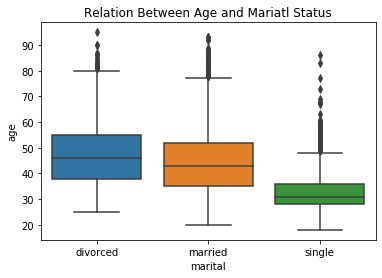

In [41]:
order = data.groupby("marital")["age"].mean().index
sns.boxplot(y=data["age"],x=data["marital"], order=order).set_title("Relation Between Age and Mariatl Status")


In [42]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Text(0.5, 1.0, 'Relation Between Age and Job')

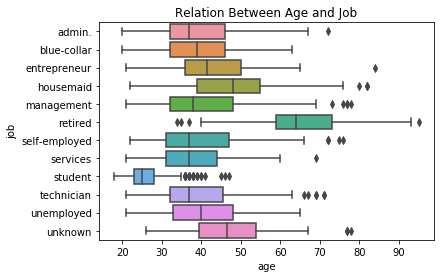

In [46]:
order = data.groupby("job")["age"].mean().index
sns.boxplot(x=data["age"],y=data["job"], order=order).set_title("Relation Between Age and Job")

Text(0.5, 1.0, 'Relation Between Age and Education')

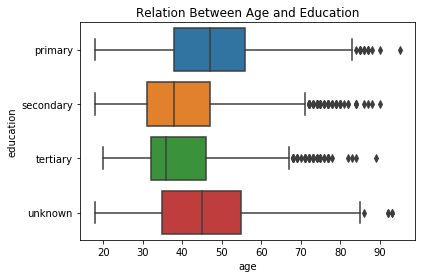

In [47]:
order = data.groupby("education")["age"].mean().index
sns.boxplot(x=data["age"],y=data["education"], order=order).set_title("Relation Between Age and Education")

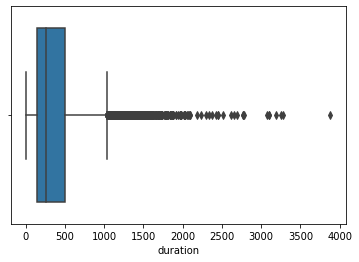

In [48]:
sns.boxplot(data["duration"])

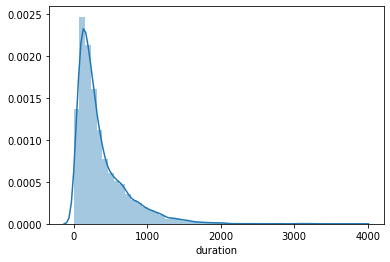

In [49]:
sns.distplot(data["duration"])

In [50]:
summary_stat(data["duration"])

mean 371.99381831213043
255.0
120487.32078242896
347.1128358076505


In [51]:
best_fit_distribution(data["duration"])

('norm', (0.0, 1.0))

In [53]:
data.groupby("job")["deposit"].value_counts()

job            deposit
admin.         no          703
               yes         631
blue-collar    no         1236
               yes         708
entrepreneur   no          205
               yes         123
housemaid      no          165
               yes         109
management     yes        1301
               no         1265
retired        yes         516
               no          262
self-employed  no          218
               yes         187
services       no          554
               yes         369
student        yes         269
               no           91
technician     no          983
               yes         840
unemployed     yes         202
               no          155
unknown        no           36
               yes          34
Name: deposit, dtype: int64

In [65]:
pd.pivot_table(data[["job","deposit"]],index=data["job"],columns="deposit",
               aggfunc='count')

job      
deposit          no   yes
job                      
admin.          703   631
blue-collar    1236   708
entrepreneur    205   123
housemaid       165   109
management     1265  1301
retired         262   516
self-employed   218   187
services        554   369
student          91   269
technician      983   840
unemployed      155   202
unknown          36    34

In [79]:
relation_job_deposit = data.groupby(["job","deposit"]).size().reset_index(name="counts")

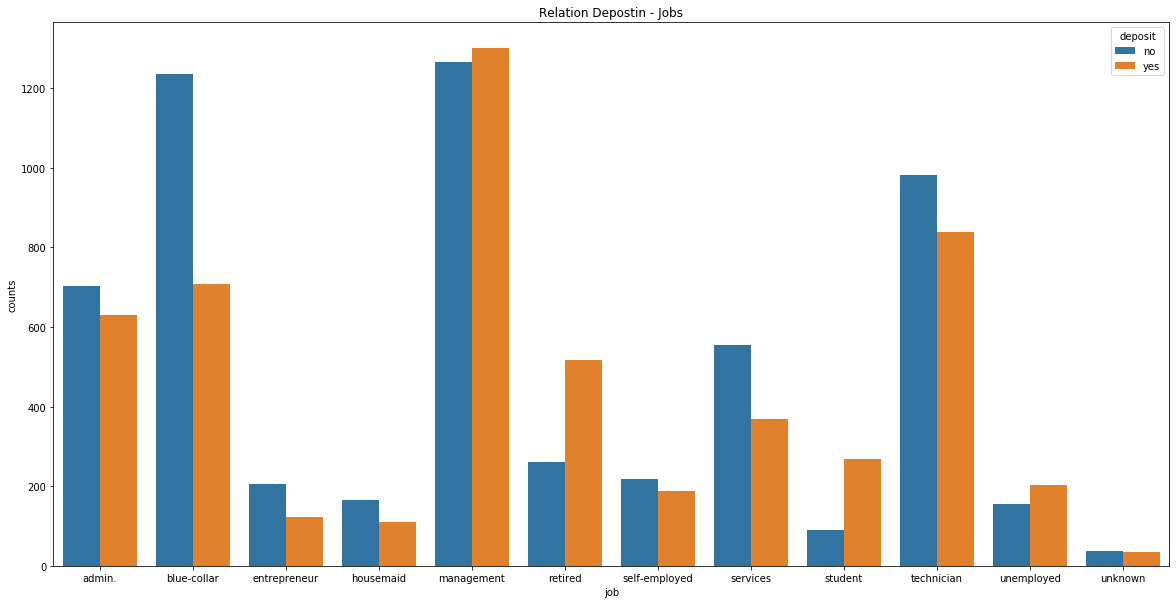

In [96]:
plt.figure(figsize=(20,10))
plt.title("Relation Depostin - Jobs")
sns.barplot(x=relation_job_deposit["job"],y=relation_job_deposit["counts"],
            hue=relation_job_deposit["deposit"])





In [97]:
data["job"].value_counts()

management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: job, dtype: int64

In [101]:
data['defaut_d'] = data["default"].map({'yes':1,"no":0})

In [104]:
data.drop('default',axis=1,inplace=True)

In [105]:
data["housing_cat"] = data['housing'].map({'yes':1, 'no':0})
data.drop('housing', axis=1,inplace = True)

In [106]:
data["loan_cat"] = data['loan'].map({'yes':1, 'no':0})
data.drop('loan', axis=1, inplace=True)

In [107]:
data.drop('month', axis=1, inplace=True)
data.drop('day', axis=1, inplace=True)

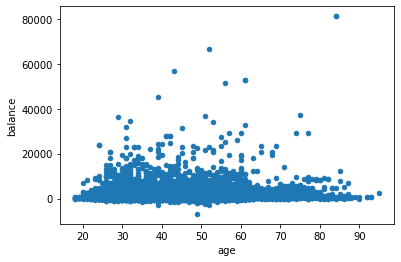

In [109]:
data.plot(kind="scatter",x="age",y="balance")

In [111]:
from scipy.stats import pearsonr


In [115]:
data["age"].corr(data["balance"])

0.11229988859873162

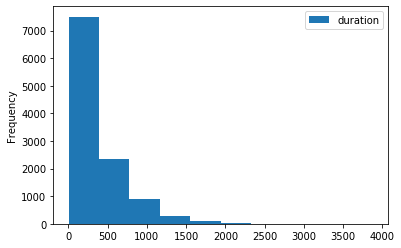

In [118]:
data.plot(kind='hist', x='poutcome', y='duration')

In [119]:
data.corr()

,age,balance,duration,campaign,pdays,previous,defaut_d,housing_cat,loan_cat
age,1.000000,0.112300,0.000189,-0.005278,0.002774,0.020169,-0.011425,-0.168700,-0.031418
balance,0.112300,1.000000,0.022436,-0.013894,0.017411,0.030805,-0.060954,-0.077092,-0.084589
duration,0.000189,0.022436,1.000000,-0.041557,-0.027392,-0.026716,-0.009760,0.035051,-0.001914
campaign,-0.005278,-0.013894,-0.041557,1.000000,-0.102726,-0.049699,0.030975,0.006660,0.034722
pdays,0.002774,0.017411,-0.027392,-0.102726,1.000000,0.507272,-0.036282,0.064497,-0.030416
previous,0.020169,0.030805,-0.026716,-0.049699,0.507272,1.000000,-0.035273,-0.000840,-0.022668
defaut_d,-0.011425,-0.060954,-0.009760,0.030975,-0.036282,-0.035273,1.000000,0.011076,0.076434
housing_cat,-0.168700,-0.077092,0.035051,0.006660,0.064497,-0.000840,0.011076,1.000000,0.076761
loan_cat,-0.031418,-0.084589,-0.001914,0.034722,-0.030416,-0.022668,0.076434,0.076761,1.000000


In [130]:
data.head()

,age,job,marital,education,balance,contact,duration,campaign,pdays,previous,poutcome,deposit,defaut_d,housing_cat,loan_cat
0,59,admin.,married,secondary,2343,unknown,1042,1,-1,0,unknown,yes,0,1,0
1,56,admin.,married,secondary,45,unknown,1467,1,-1,0,unknown,yes,0,0,0
2,41,technician,married,secondary,1270,unknown,1389,1,-1,0,unknown,yes,0,1,0
3,55,services,married,secondary,2476,unknown,579,1,-1,0,unknown,yes,0,1,0
4,54,admin.,married,tertiary,184,unknown,673,2,-1,0,unknown,yes,0,0,0


In [131]:
data = data.drop("contact",axis=1)

In [132]:
bank_with_dummies = pd.get_dummies(data=data, columns = ['job', 'marital', 'education', 'poutcome'], \
                                   prefix = ['job', 'marital', 'education', 'poutcome'])

In [133]:
bank_with_dummies.head()

,age,balance,duration,campaign,pdays,previous,deposit,defaut_d,housing_cat,loan_cat,...,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,1042,1,-1,0,yes,0,1,0,...,1,0,0,1,0,0,0,0,0,1
1,56,45,1467,1,-1,0,yes,0,0,0,...,1,0,0,1,0,0,0,0,0,1
2,41,1270,1389,1,-1,0,yes,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,55,2476,579,1,-1,0,yes,0,1,0,...,1,0,0,1,0,0,0,0,0,1
4,54,184,673,2,-1,0,yes,0,0,0,...,1,0,0,0,1,0,0,0,0,1


In [135]:
explained = bank_with_dummies.drop("deposit",axis=1)
target = bank_with_dummies["deposit"]
X_train,X_test,y_train,y_test = train_test_split(explained,target,test_size=0.3,
                                                random_state = 1234)


In [138]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif["features"] = X_train.columns

In [140]:
vif

,VIF Factor,features
0,2.043638,age
1,1.035715,balance
2,1.014449,duration
3,1.031680,campaign
4,3.480642,pdays
5,1.641516,previous
6,1.018741,defaut_d
7,1.174306,housing_cat
8,1.050258,loan_cat
9,inf,job_admin.


In [143]:
from sklearn import tree
X = explained
Y = target
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, Y)
print(clf.tree_.max_depth)

29


In [150]:
clf = DecisionTreeClassifier(max_depth=12).fit(X_train,y_train)
print(clf.score(X_train,y_train))
print(clf.score(X_test,y_test))


0.8965826187124024
0.7802329053448791


In [158]:
features = bank_with_dummies.drop("deposit",axis=1).columns.tolist()

In [159]:
features

['age',
 'balance',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'defaut_d',
 'housing_cat',
 'loan_cat',
 'job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_divorced',
 'marital_married',
 'marital_single',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'poutcome_failure',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown']

In [160]:
dt2 = tree.DecisionTreeClassifier(random_state=1, max_depth=2)

# Fit the decision tree classifier
dt2.fit(X_train, y_train)

fi = dt2.feature_importances_

l = len(features)
for i in range(0,len(features)):
    print('{:.<20} {:3}'.format(features[i],fi[i]))

age................. 0.0
balance............. 0.0
duration............ 0.8536210662811285
campaign............ 0.0
pdays............... 0.0
previous............ 0.0
defaut_d............ 0.0
housing_cat......... 0.0
loan_cat............ 0.0
job_admin........... 0.0
job_blue-collar..... 0.0
job_entrepreneur.... 0.0
job_housemaid....... 0.0
job_management...... 0.0
job_retired......... 0.0
job_self-employed... 0.0
job_services........ 0.0
job_student......... 0.0
job_technician...... 0.0
job_unemployed...... 0.0
job_unknown......... 0.0
marital_divorced.... 0.0
marital_married..... 0.0
marital_single...... 0.0
education_primary... 0.0
education_secondary. 0.0
education_tertiary.. 0.0
education_unknown... 0.0
poutcome_failure.... 0.0
poutcome_other...... 0.0
poutcome_success.... 0.1463789337188714
poutcome_unknown.... 0.0


In [161]:
from sklearn.tree import plot_tree

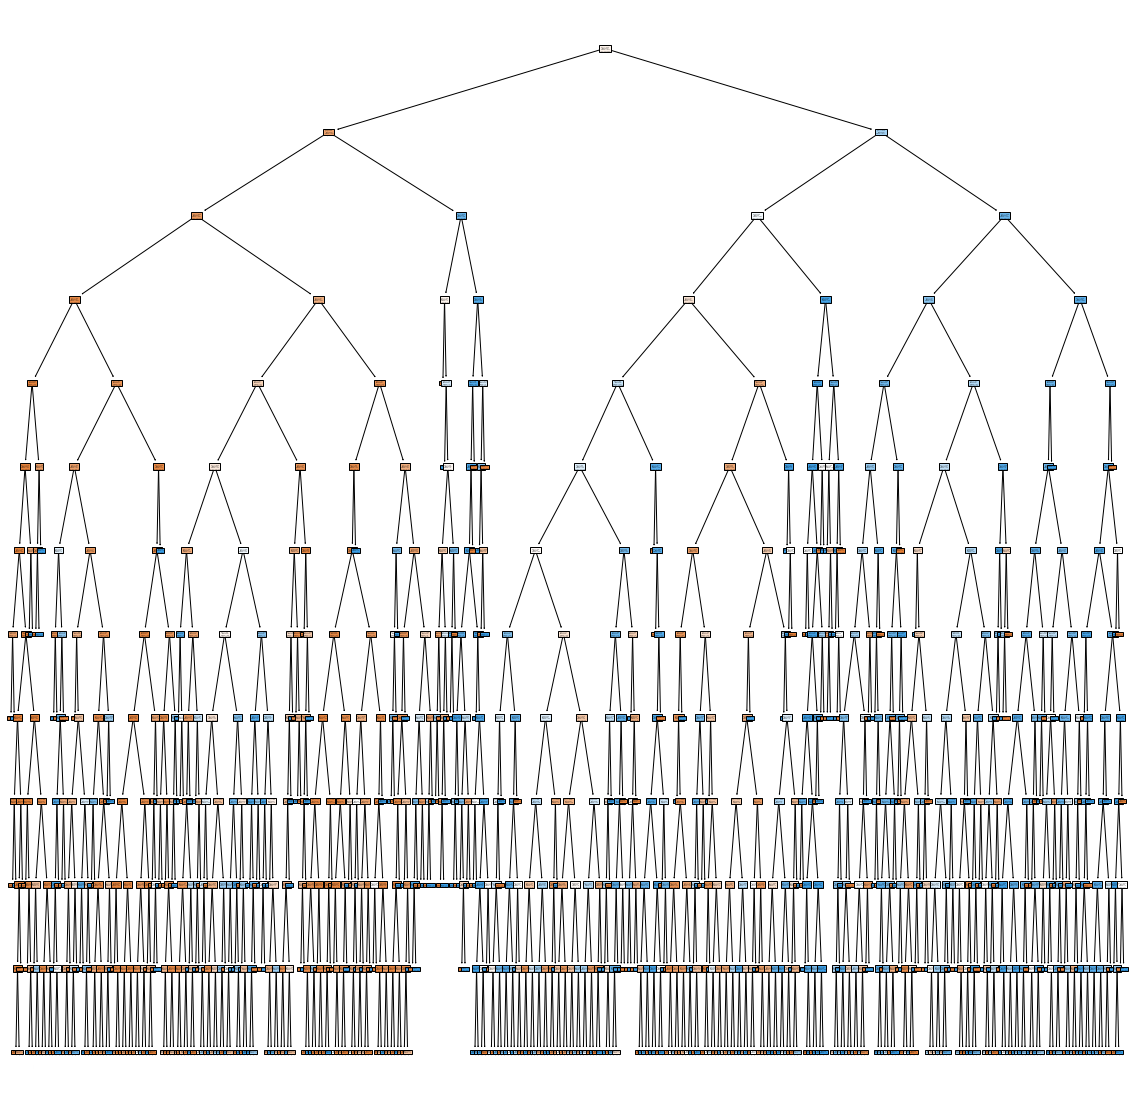

In [167]:
plt.figure(figsize=(20,20))
plot_tree(clf,filled=True)
plt.show()

In [177]:
print(clf.predict_proba(np.array([0, 0, 189, 0, 0, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0]).reshape(1, -1)))
print(clf.predict(np.array([0, 0, 24, 0, 0, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0]).reshape(1, -1)))

[[0. 1.]]
['no']


In [180]:
predicts=clf.predict(X_test)
print(metrics.accuracy_score(y_test,predicts))

0.7802329053448791


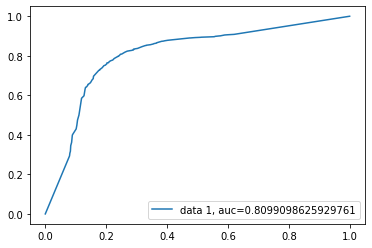

In [189]:
y_test = y_test.map({'yes':1, 'no':0})
y_pred_proba = clf.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [192]:
probs = dt2.predict_proba(X_test)[:,1]
metrics.roc_auc_score(y_test, probs)

0.7934053346424481

In [188]:
y_test = y_test.map({'yes':1, 'no':0})
